In [ ]:
%pip install 'stable-baselines3[extra]'
%pip install sb3-contrib

In [2]:
import os
import time

import gymnasium as gym
from stable_baselines3.common.monitor import Monitor

from blackjack_env.wrappers import ShiftWrapper, SafeV1ActionWrapper
from blackjack_env.agent_utils.sb3_ppo import test_env_PPO

log_dir = os.path.abspath(f"../results/sb3_blackjack_{int(time.time())}")
os.makedirs(log_dir, exist_ok=True)


def make_env(log_dir: str, seed: int) -> gym.Env:
    env = gym.make("Blackjack4game-v1", render_mode=None)
    env = ShiftWrapper(env)
    env = SafeV1ActionWrapper(env)
    env = Monitor(env, filename=os.path.join(log_dir, "monitor.csv"))
    env.reset(seed=seed)
    return env


def make_evaluation_env(seed: int) -> gym.Env:
    env = gym.make("Blackjack4game-v1", render_mode=None)
    env = ShiftWrapper(env)
    env = SafeV1ActionWrapper(env)
    env.reset(seed=seed)
    return env

In [3]:
ppo_kwargs_base = dict(
    learning_rate=3e-4,
    n_steps=2048,
    batch_size=256,
    n_epochs=10,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.01,
    vf_coef=0.5,
    max_grad_norm=0.5,
)

ppo_kwargs_stable_slow = dict(
    learning_rate=1e-4,
    n_steps=4096,
    batch_size=256,
    n_epochs=10,
    gamma=0.995,
    gae_lambda=0.95,
    clip_range=0.15,
    ent_coef=0.005,
)

ppo_kwargs_fast = dict(
    learning_rate=1e-3,
    n_steps=1024,
    batch_size=128,
    n_epochs=5,
    gamma=0.99,
    gae_lambda=0.9,
    clip_range=0.2,
    ent_coef=0.02,
)

ppo_kwargs_explore = dict(
    learning_rate=3e-4,
    n_steps=2048,
    batch_size=256,
    n_epochs=10,
    ent_coef=0.05,  # większa entropia
    gamma=0.99,
    gae_lambda=0.95,
)

HP_SETS = [
    (
        "fast",
        dict(
            learning_rate=1e-3,
            n_steps=1024,
            batch_size=1024,
            n_epochs=5,
            gamma=0.99,
            gae_lambda=0.90,
            clip_range=0.20,
            ent_coef=0.01,
            vf_coef=0.5,
            max_grad_norm=0.5,
        ),
    ),
    (
        "base_fast",
        dict(
            learning_rate=3e-4,
            n_steps=2048,
            batch_size=1024,
            n_epochs=5,
            gamma=0.99,
            gae_lambda=0.95,
            clip_range=0.20,
            ent_coef=0.01,
            vf_coef=0.5,
            max_grad_norm=0.5,
        ),
    ),
    (
        "explore_fast",
        dict(
            learning_rate=3e-4,
            n_steps=2048,
            batch_size=1024,
            n_epochs=5,
            gamma=0.99,
            gae_lambda=0.95,
            clip_range=0.20,
            ent_coef=0.03,  # trochę więcej eksploracji, bez przesady
            vf_coef=0.5,
            max_grad_norm=0.5,
        ),
    ),
]

/home/jakseluz/nauka/VI_semestr/inteligencja_obliczeniowa_w_analizie_danych_cyfrowych/.venv/lib/python3.14/site-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/jakseluz/nauka/VI_semestr/inteligencja_obliczeniowa_w_analizie_danych_cyfrowych/.venv/lib/python3.14/site-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(



=== fast ===
Starting run 1/10 with seed 42...
Using cuda device
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 3.19     |
|    ep_rew_mean     | -0.172   |
| time/              |          |
|    fps             | 740      |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 1024     |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 3.22         |
|    ep_rew_mean          | -0.0397      |
| time/                   |              |
|    fps                  | 708          |
|    iterations           | 2            |
|    time_elapsed         | 2            |
|    total_timesteps      | 2048         |
| train/                  |              |
|    approx_kl            | 0.0012856962 |
|    clip_fraction        | 0.000391     |
|    clip_range           | 0.2          |


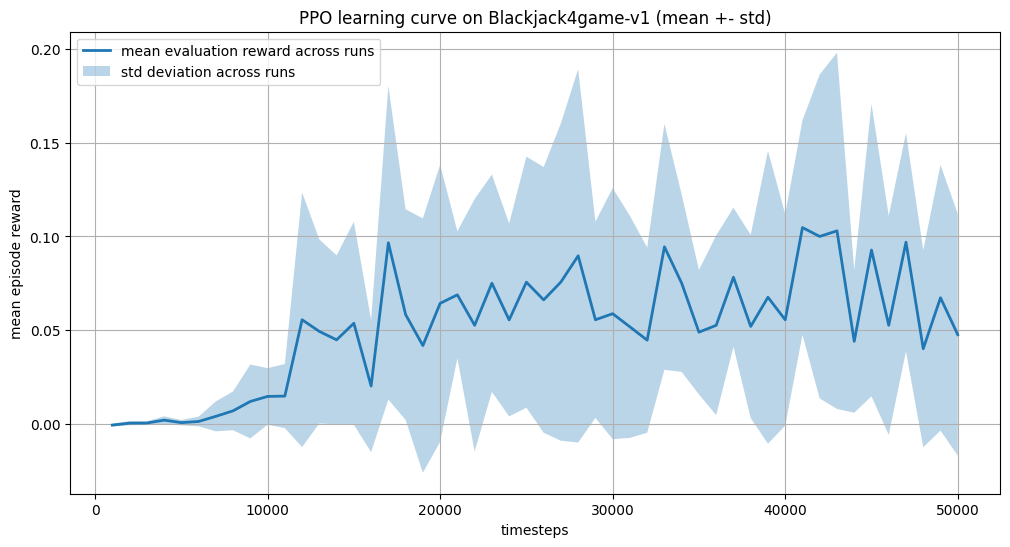

/home/jakseluz/nauka/VI_semestr/inteligencja_obliczeniowa_w_analizie_danych_cyfrowych/.venv/lib/python3.14/site-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/jakseluz/nauka/VI_semestr/inteligencja_obliczeniowa_w_analizie_danych_cyfrowych/.venv/lib/python3.14/site-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(



=== base_fast ===
Starting run 1/10 with seed 42...
Using cuda device
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 3.21     |
|    ep_rew_mean     | -0.114   |
| time/              |          |
|    fps             | 995      |
|    iterations      | 1        |
|    time_elapsed    | 2        |
|    total_timesteps | 2048     |
---------------------------------
-------------------------------------------
| rollout/                |               |
|    ep_len_mean          | 3.35          |
|    ep_rew_mean          | -0.142        |
| time/                   |               |
|    fps                  | 966           |
|    iterations           | 2             |
|    time_elapsed         | 4             |
|    total_timesteps      | 4096          |
| train/                  |               |
|    approx_kl            | 0.00044609446 |
|    clip_fraction        | 0             |
|    clip_range           

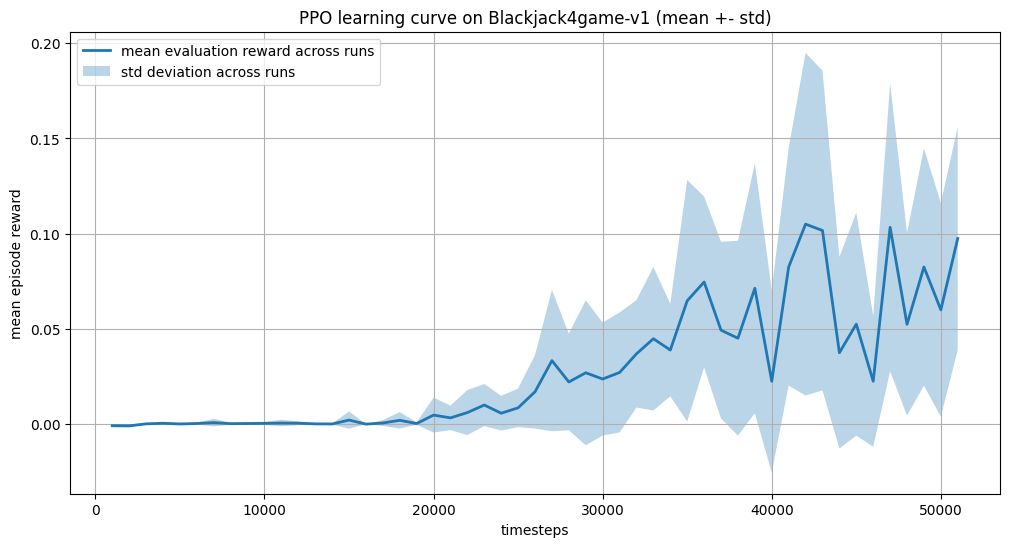


=== explore_fast ===
Starting run 1/10 with seed 42...
Using cuda device
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 3.21     |
|    ep_rew_mean     | -0.114   |
| time/              |          |
|    fps             | 1084     |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 2048     |
---------------------------------
-------------------------------------------
| rollout/                |               |
|    ep_len_mean          | 3.35          |
|    ep_rew_mean          | -0.142        |
| time/                   |               |
|    fps                  | 1080          |
|    iterations           | 2             |
|    time_elapsed         | 3             |
|    total_timesteps      | 4096          |
| train/                  |               |
|    approx_kl            | 0.00044853459 |
|    clip_fraction        | 0             |
|    clip_range        

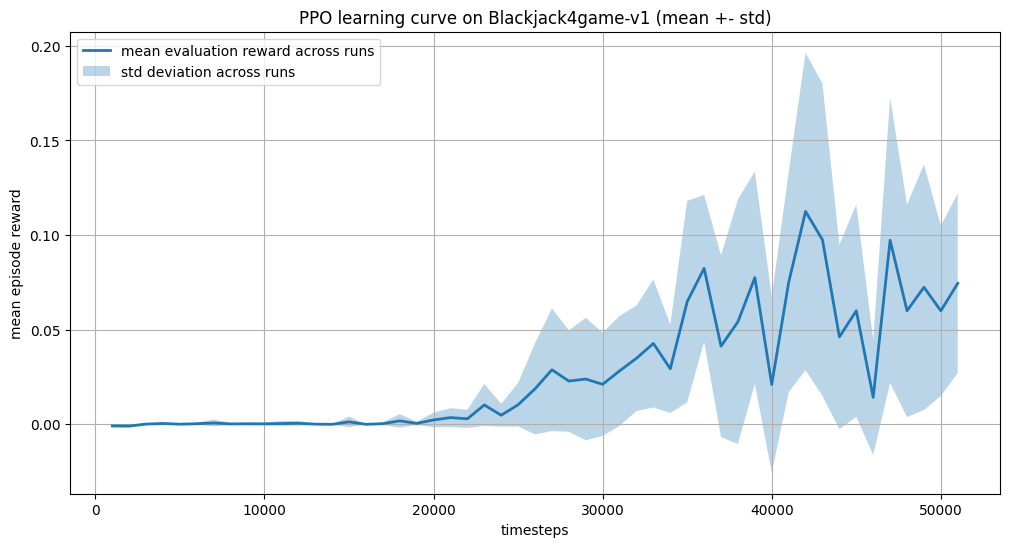

In [4]:
BASE = dict(
    policy="MultiInputPolicy",
    verbose=1,
    n_runs=10,
    run_timesteps=50_000,
    eval_freq=1_000,
    n_eval_episodes=20,
    base_seed=42,
)

for name, hp in HP_SETS:
    run_log_dir = os.path.join(log_dir, name)
    os.makedirs(run_log_dir, exist_ok=True)

    env_train = make_env(log_dir=run_log_dir, seed=BASE["base_seed"])
    env_eval = make_evaluation_env(seed=BASE["base_seed"] + 10_000)

    print(f"\n=== {name} ===")
    test_env_PPO(
        env_train=env_train,
        env_eval=env_eval,
        **BASE,
        **hp,
    )